# Under the hood: the zarr store itself

xarray is a convenience layer — a zarr store is just **chunked, compressed
arrays plus JSON metadata over HTTP**, and the `zarr` package reads it
directly. Knowing the anatomy explains *why* the habits from notebook 02 work:
metadata is one consolidated document, and every read fetches only the chunks
under your slice.

Requirements: `pip install "zarr>=3" xarray matplotlib requests`.

In [1]:
import zarr

g = zarr.open_group("https://zarr.icos-cp.eu/icos-obspack.zarr/CBW207",
                    mode="r")                      # URL works directly
a = g["co2"]
n_chunks = -(-a.shape[0] // a.chunks[0])
print("array :", a.shape, a.dtype, "| chunks:", a.chunks, f"→ {n_chunks} chunks")
print("codecs:", a.compressors)

array : (296266,) float32 | chunks: (74067,) → 4 chunks
codecs: (Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),)


In [2]:
# Slicing the zarr array fetches ONLY the chunks under the slice —
# this reads 1 of the chunks, not the 30-year series:
piece = a[:1000]
print(piece[:5], "…", f"({piece.size} values)")
print()
print("attrs ride in the same metadata — no extra request:")
print(" ", g.attrs["station_name"], "/", g.attrs["co2_dataset_name"])

[360.125   361.33102 361.53702 362.94302 361.866  ] … (1000 values)

attrs ride in the same metadata — no extra request:
  Cabauw / co2_cbw_tower-insitu_445_207magl


## One request, whole-store inventory

Notebook 02 told you *not* to open the store root for a single series (its
consolidated metadata is ~16 MB vs ~0.2 MB per group). Building an inventory
of **all** stations is the one job where the root document earns that cost —
every group's attributes arrive in a single fetch, and the sweep itself is
instant:

In [3]:
import pandas as pd

root = zarr.open_group("https://zarr.icos-cp.eu/icos-obspack.zarr", mode="r")
rows = [{"id": name, "name": grp.attrs.get("station_name", ""),
         "lat": grp.attrs.get("latitude"), "lon": grp.attrs.get("longitude"),
         "height_m": grp.attrs.get("sampling_height")}
        for name, grp in root.groups()
        if "station_name" in grp.attrs]        # stations only, not combined views
inv = pd.DataFrame(rows).set_index("id")
print(len(inv), "station groups")
inv.head(6)

165 station groups


,name,lat,lon,height_m
id,,,,
ARN10,El Arenosillo,37.1040,-6.7340,10.0
ARN50,El Arenosillo,37.1040,-6.7340,50.0
ARN95,El Arenosillo,37.1040,-6.7340,95.0
BIK180,Bialystok,53.2294,23.0128,180.0
BIK30,Bialystok,53.2294,23.0128,30.0
BIK300,Bialystok,53.2294,23.0128,300.0


## A gridded cube, lazily

The same chunk arithmetic is what makes gridded products browsable. The
global SOCAT grid (`socat-gridded.zarr`, monthly 1°×1° since 1970) is
`(time, lat, lon)` — a month-map or a decade of one region each touch only
their chunks:

{'time': 577, 'lat': 180, 'lon': 360} | chunks: (120, 180, 360)


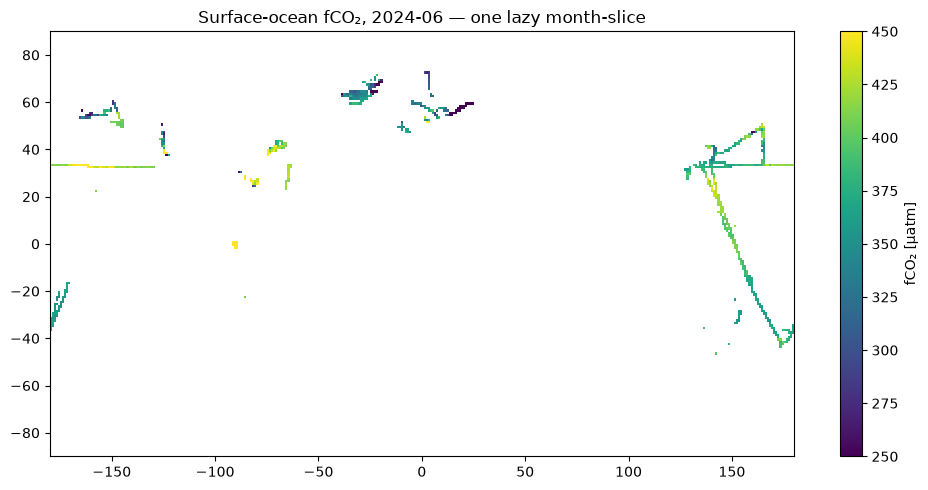

In [4]:
import matplotlib.pyplot as plt
import numpy as np, xarray as xr

gr = xr.open_zarr("https://zarr.icos-cp.eu/socat-gridded.zarr",
                  consolidated=True)               # lazy
fco2 = gr["fco2_ave_weighted"]
print(dict(fco2.sizes), "| chunks:", fco2.encoding.get("chunks"))

june = fco2.sel(time="2024-06-15", method="nearest").load()   # one month-map
fig, ax = plt.subplots(figsize=(10, 5))
pm = ax.pcolormesh(gr.lon, gr.lat, june, cmap="viridis", vmin=250, vmax=450)
fig.colorbar(pm, label="fCO₂ [µatm]")
ax.set_title(f"Surface-ocean fCO₂, {str(june.time.values)[:7]} — one lazy month-slice")
fig.tight_layout()

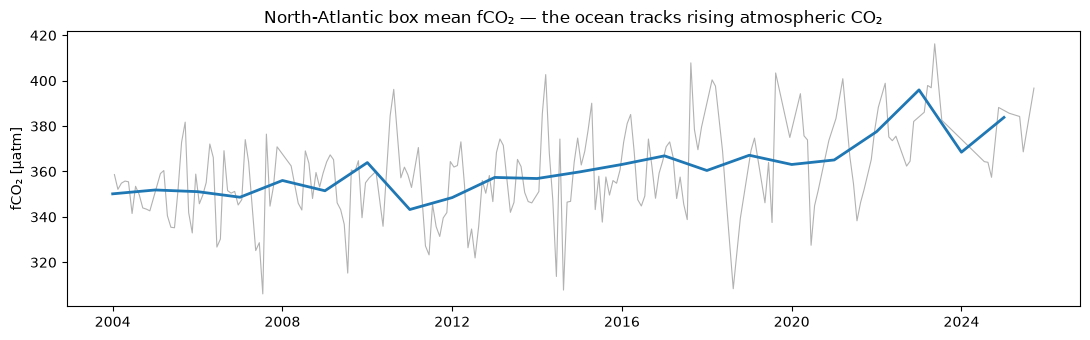

In [5]:
# The other axis: two decades of the central North Atlantic — a small box
# across many time chunks, still only the covering chunks move.
box = (fco2.sel(lat=slice(40, 55), lon=slice(-40, -15))
       .mean(("lat", "lon")).load())
s = box.to_series().dropna()["2004":]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(s.index, s.values, lw=0.8, color="tab:gray", alpha=0.6)
ax.plot(s.resample("YS").mean(), lw=2, color="tab:blue")
ax.set_ylabel("fCO₂ [µatm]")
ax.set_title("North-Atlantic box mean fCO₂ — the ocean tracks rising atmospheric CO₂")
fig.tight_layout()

In [6]:
print("citation:", gr.attrs.get("collection_citation", "")[:180], "…")
import requests
r = requests.get("https://zarr.icos-cp.eu/socat-gridded.zarr/session/passport").json()
rec = r["passport"]["@graph"][1]
print("session passport:", rec["accessedArrays"], "|", rec["dateAccessed"])

citation: Bakker, D. C. E., et al. Surface Ocean CO2 Atlas Database Version 2026 (SOCATv2026) (NCEI Accession). NOAA National Centers for Environmental Information. https://doi.org/10.25921/ …
session passport: ['fco2_ave_weighted', 'lat', 'lon', 'time'] | 2026-08-17T17:11:10Z
